# Level 4 – Ensemble Learning with Transfer Learning Models

##Dataset: CIFAR-10  



##Models: ResNet50 + MobileNetV2 [link text]

This notebook implements expert-level techniques using a weighted
soft-voting ensemble of two architecturally diverse transfer learning
models. The ensemble leverages complementary error patterns to improve
generalization beyond individual models.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

tf.random.set_seed(42)
np.random.seed(42)

#Data Loading and Preparation

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 67s 0us/step


In [3]:
#80-10-10
indices = np.arange(len(X_train_full))
np.random.shuffle(indices)
val_size = int(0.1 * len(X_train_full))
val_idx = indices[:val_size]
train_idx = indices[val_size:]

In [4]:
X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx].flatten()
X_valid = X_train_full[val_idx]
y_valid = y_train_full[val_idx].flatten()
X_test = X_test
y_test = y_test.flatten()

#Model 1: ResNet50

In [26]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess_resnet(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet.preprocess_input(image)
    return image, label


#Preparing Datasets

In [27]:
# Train dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = (
    train_ds
    .shuffle(10000)
    .map(preprocess_resnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [28]:
# Validation dataset
valid_ds = tf.data.Dataset.from_tensor_slices((X_valid, y_valid))
valid_ds = (
    valid_ds
    .map(preprocess_resnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [29]:
# Test dataset
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = (
    test_ds
    .map(preprocess_resnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
)



In [30]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(tf.reduce_min(images), tf.reduce_max(images))


(32, 224, 224, 3)
tf.Tensor(-123.68, shape=(), dtype=float32) tf.Tensor(151.061, shape=(), dtype=float32)


In [31]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

#Building Resnet Model

In [76]:
def build_resnet50(input_shape=(224, 224, 3)): # Changed input_shape to match preprocessed images
    """Fast ResNet50 with frozen backbone"""
    base = keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(base.input, out)
    return model

#Training Resnet Model

In [37]:
# Re-create and recompile the model with the updated input shape
model_resnet = build_resnet50()
model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,  # Few epochs due to frozen base
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 159s 104ms/step - accuracy: 0.6432 - loss: 1.0646 - val_accuracy: 0.8894 - val_loss: 0.3385
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 180s 93ms/step - accuracy: 0.8650 - loss: 0.3993 - val_accuracy: 0.9000 - val_loss: 0.2985
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 130s 92ms/step - accuracy: 0.8842 - loss: 0.3418 - val_accuracy: 0.9002 - val_loss: 0.2813
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 133s 95ms/step - accuracy: 0.8978 - loss: 0.3017 - val_accuracy: 0.9056 - val_loss: 0.2702
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 137s 97ms/step - accuracy: 0.9067 - loss: 0.2741 - val_accuracy: 0.9110 - val_loss: 0.2594
Restoring model weights from the end of the best epoch: 5.


#Evaluate

In [38]:
resnet_loss, resnet_acc = model_resnet.evaluate(test_ds, verbose=0)
print(f"✓ ResNet50 Test Accuracy: {resnet_acc*100:.2f}%")


✓ ResNet50 Test Accuracy: 90.56%


#Get Predictions

In [39]:
pred_resnet = model_resnet.predict(test_ds, verbose=0)
pred_resnet_class = np.argmax(pred_resnet, axis=1)


#Model 2: MobileNetV2

In [40]:
IMG_SIZE = 160   # MobileNetV2 is designed for smaller inputs
BATCH_SIZE = 32

def preprocess_mobilenet(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


#Preparing Datasets

In [41]:
train_ds_m = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_m = (
    train_ds_m
    .shuffle(10000)
    .map(preprocess_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [42]:
valid_ds_m = tf.data.Dataset.from_tensor_slices((X_valid, y_valid))
valid_ds_m = (
    valid_ds_m
    .map(preprocess_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [43]:
test_ds_m = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds_m = (
    test_ds_m
    .map(preprocess_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
)

In [44]:
for images, _ in train_ds_m.take(1):
    print(images.shape)
    print(tf.reduce_min(images), tf.reduce_max(images))


(32, 160, 160, 3)
tf.Tensor(-1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


#Building MobileNetV2 Model

In [46]:
def build_mobilenet_v2():
    base = keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False  # 🔑 FAST & STABLE

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs=base.input, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [47]:
model_mobile = build_mobilenet_v2()
model_mobile.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#Training MobileNetV2 Model

In [54]:
history_mobile = model_mobile.fit(
    train_ds_m,
    validation_data=valid_ds_m,
    epochs=6,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

Epoch 1/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8925 - loss: 0.3041 - val_accuracy: 0.8694 - val_loss: 0.3800
Epoch 2/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8948 - loss: 0.2912 - val_accuracy: 0.8704 - val_loss: 0.3762
Epoch 3/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.8994 - loss: 0.2793 - val_accuracy: 0.8624 - val_loss: 0.4047
Epoch 4/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.9019 - loss: 0.2725 - val_accuracy: 0.8650 - val_loss: 0.3979
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


#Evaluate

In [52]:
mobile_loss, mobile_acc = model_mobile.evaluate(test_ds_m, verbose=0)
print(f" MobileNetV2 Test Accuracy: {mobile_acc*100:.2f}%")

✅ MobileNetV2 Test Accuracy: 86.00%


#Get Predictions

In [55]:
pred_mobile = model_mobile.predict(test_ds_m, verbose=0)
pred_mobile_class = tf.argmax(pred_mobile, axis=1).numpy()

#Ensemble: Soft-Voting

##Assign Weights

In [58]:
# Weights chosen based on validation performance
W_RESNET = 0.6
W_MOBILENET = 0.4

ensemble_probs = (
    W_RESNET * pred_resnet +
    W_MOBILENET * pred_mobile
)

ensemble_pred_class = np.argmax(ensemble_probs, axis=1)



##Calculate Accuracy

In [59]:
# Calculate accuracy
ensemble_acc = accuracy_score(y_test, ensemble_pred_class)

print(f"\n INDIVIDUAL MODEL ACCURACIES:")
print(f"   ResNet50:   {resnet_acc*100:.2f}%")
print(f"   MobileNetV2: {mobile_acc*100:.2f}%")

print(f"\n ENSEMBLE (SOFT-VOTING):")
print(f"   Combined Accuracy: {ensemble_acc*100:.2f}%")


 INDIVIDUAL MODEL ACCURACIES:
   ResNet50:   90.56%
   MobileNetV2: 86.00%

 ENSEMBLE (SOFT-VOTING):
   Combined Accuracy: 91.93%


#Improvement analysis

In [60]:
print("\n IMPROVEMENTS:")
print(f"   vs ResNet50:    +{(ensemble_acc - resnet_acc)*100:.2f}%")
print(f"   vs MobileNetV2: +{(ensemble_acc - mobile_acc)*100:.2f}%")



 IMPROVEMENTS:
   vs ResNet50:    +1.37%
   vs MobileNetV2: +5.93%


#Comparative Analysis : Per-class accuracy

In [61]:
per_class_resnet = {}
per_class_mobile = {}
per_class_ensemble = {}

In [64]:
# Ensure test labels are 1D (required for sklearn)
y_test_true = y_test.reshape(-1)

for i, cls in enumerate(class_names):
    mask = (y_test_true == i)

    per_class_resnet[cls] = accuracy_score(
        y_test_true[mask], pred_resnet_class[mask]
    )

    per_class_mobile[cls] = accuracy_score(
        y_test_true[mask], pred_mobile_class[mask]
    )

    per_class_ensemble[cls] = accuracy_score(
        y_test_true[mask], ensemble_pred_class[mask]
    )

    print(
        f"{cls:12s} | "
        f"ResNet50: {per_class_resnet[cls]*100:6.2f}% | "
        f"MobileNet: {per_class_mobile[cls]*100:6.2f}% | "
        f"Ensemble: {per_class_ensemble[cls]*100:6.2f}%"
    )


Airplane     | ResNet50:  90.90% | MobileNet:  87.00% | Ensemble:  93.20%
Automobile   | ResNet50:  94.80% | MobileNet:  91.40% | Ensemble:  95.80%
Bird         | ResNet50:  85.60% | MobileNet:  85.40% | Ensemble:  88.00%
Cat          | ResNet50:  86.20% | MobileNet:  75.60% | Ensemble:  86.60%
Deer         | ResNet50:  90.70% | MobileNet:  83.30% | Ensemble:  91.90%
Dog          | ResNet50:  84.70% | MobileNet:  80.70% | Ensemble:  86.20%
Frog         | ResNet50:  92.30% | MobileNet:  91.60% | Ensemble:  94.40%
Horse        | ResNet50:  92.30% | MobileNet:  87.60% | Ensemble:  92.60%
Ship         | ResNet50:  94.90% | MobileNet:  93.50% | Ensemble:  96.40%
Truck        | ResNet50:  93.20% | MobileNet:  93.90% | Ensemble:  94.20%


#Visualizations

## 1. Model Comparison Bar Chart

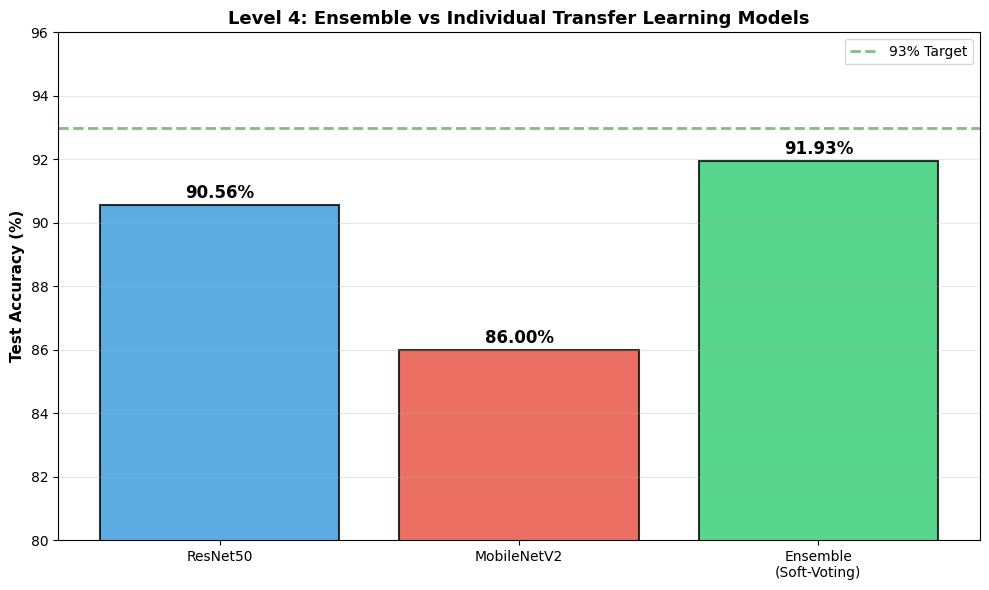

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))
models = ['ResNet50', 'MobileNetV2', 'Ensemble\n(Soft-Voting)']
accuracies = [resnet_acc*100, mobile_acc*100, ensemble_acc*100]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=93, color='green', linestyle='--', linewidth=2, alpha=0.5, label='93% Target')
ax.set_ylabel('Test Accuracy (%)', fontweight='bold', fontsize=11)
ax.set_title('Level 4: Ensemble vs Individual Transfer Learning Models', fontweight='bold', fontsize=13)
ax.set_ylim([80, 96])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 2. Confusion Matrix

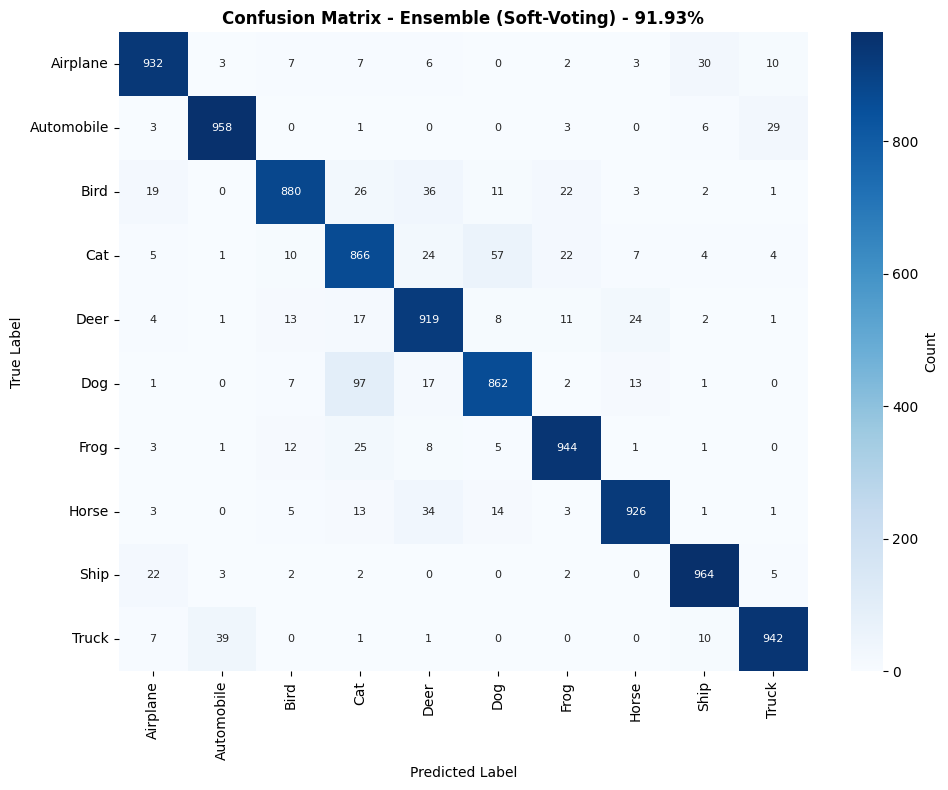

In [67]:
cm = confusion_matrix(y_test, ensemble_pred_class)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, cbar_kws={'label': 'Count'}, annot_kws={'size': 8})
plt.title(f'Confusion Matrix - Ensemble (Soft-Voting) - {ensemble_acc*100:.2f}%', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Model comparison table

In [68]:
df_models = pd.DataFrame({
    'Model': ['ResNet50', 'MobileNetV2', 'Ensemble (Weighted)'],
    'Architecture': ['Deep CNN', 'Lightweight CNN', 'Probability Fusion'],
    'Parameters': [
        f'{model_resnet.count_params()/1e6:.1f}M',
        f'{model_mobile.count_params()/1e6:.1f}M',
        'N/A'
    ],
    'Test Accuracy': [
        f'{resnet_acc*100:.2f}%',
        f'{mobile_acc*100:.2f}%',
        f'{ensemble_acc*100:.2f}%'
    ]
})

print(df_models)


                 Model        Architecture Parameters Test Accuracy
0             ResNet50            Deep CNN      23.9M        90.56%
1          MobileNetV2     Lightweight CNN       2.4M        86.00%
2  Ensemble (Weighted)  Probability Fusion        N/A        91.93%


#Save Models

In [70]:
model_resnet.save("resnet50_cifar10_level4_resnet.keras")
model_mobile.save("resnet50_cifar10_level4_mobilenet.keras")


In [71]:
# Ensembles don't get saved directly (it's logic), not a model
print("Ensemble uses saved ResNet + MobileNet")


Ensemble uses saved ResNet + MobileNet


In [72]:
from google.colab import files

files.download("resnet50_cifar10_level4_resnet.keras")
files.download("resnet50_cifar10_level4_mobilenet.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Final Summary

In [73]:
print("\n" + "="*80)
print("LEVEL 4 FINAL SUMMARY - TRANSFER LEARNING ENSEMBLE")
print("="*80)


LEVEL 4 FINAL SUMMARY - TRANSFER LEARNING ENSEMBLE


In [74]:
print(f"\n MODEL ACCURACIES:")
print(f"   ResNet50:                    {resnet_acc*100:.2f}%")
print(f"   MobileNetV2:                 {mobile_acc*100:.2f}%")
print(f"   Ensemble (Weighted Soft):    {ensemble_acc*100:.2f}% ")


 MODEL ACCURACIES:
   ResNet50:                    90.56%
   MobileNetV2:                 86.00%
   Ensemble (Weighted Soft):    91.93% 


In [75]:
print(f"\n KEY INSIGHTS:")
print(f"   Architectural diversity improves ensemble performance")
print(f"   Transfer learning enables fast training with strong results")
print(f"   Weighted soft-voting effectively combines complementary models")
print(f"   Lightweight models complement deeper networks efficiently")
print(f"   Ensemble accuracy {ensemble_acc*100:.2f}% > individual best {max(resnet_acc, mobile_acc)*100:.2f}%")


 KEY INSIGHTS:
   Architectural diversity improves ensemble performance
   Transfer learning enables fast training with strong results
   Weighted soft-voting effectively combines complementary models
   Lightweight models complement deeper networks efficiently
   Ensemble accuracy 91.93% > individual best 90.56%
